In [28]:
# importing libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

# loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [29]:
df_DA =df[df['job_title_short'] == 'Data Analyst'].copy()

In [30]:
df_DA['job_posted_month_no'] = df_DA['job_posted_date'].dt.month

In [31]:
df_DA_exploded = df_DA.explode('job_skills')
df_DA_pivot = df_DA_exploded.pivot_table(index='job_posted_month_no', columns='job_skills', aggfunc='size', fill_value=0)
df_DA_pivot.loc['Total'] = df_DA_pivot.sum()
df_DA_pivot = df_DA_pivot.sort_values(by='Total', axis=1, ascending=False)
df_DA_pivot.drop('Total', inplace=True)
df_DA_pivot

job_skills,sql,excel,python,tableau,power bi,r,sas,powerpoint,word,sap,...,xamarin,mattermost,gtx,esquisse,chainer,capacitor,nuxt.js,msaccess,ovh,suse
job_posted_month_no,,,,,,,,,,,,,,,,,,,,,
1,11336,8170,6606,5596,4285,3607,3830,1880,1778,1251,...,0,0,0,0,0,1,1,0,0,0
2,7947,5772,4751,3936,3307,2576,2634,1291,1235,954,...,0,0,0,0,0,0,0,0,0,0
3,7868,5675,4741,4051,3176,2650,2554,1266,1203,892,...,1,0,0,0,0,0,0,0,0,1
4,7553,5496,4557,3776,3106,2399,2598,1190,1177,947,...,0,0,0,0,0,0,0,0,1,0
5,6617,4773,4070,3245,2695,2093,1940,979,957,851,...,0,0,0,0,0,0,0,1,0,0
6,7584,5724,4707,3812,3275,2442,2174,1173,1237,987,...,0,0,0,0,0,0,0,0,0,0
7,7687,5513,4831,3928,3350,2444,2118,1096,1069,996,...,0,0,1,0,0,0,0,0,0,0
8,8823,6482,5576,4533,3859,2975,2560,1332,1298,1117,...,0,0,0,0,0,0,0,0,0,0
9,6829,4886,4229,3446,3118,2146,1880,944,945,852,...,0,1,0,0,0,0,0,0,0,0


In [32]:
df_DA_pivot.reset_index(inplace=True)
df_DA_pivot

job_skills,job_posted_month_no,sql,excel,python,tableau,power bi,r,sas,powerpoint,word,...,xamarin,mattermost,gtx,esquisse,chainer,capacitor,nuxt.js,msaccess,ovh,suse
0,1,11336,8170,6606,5596,4285,3607,3830,1880,1778,...,0,0,0,0,0,1,1,0,0,0
1,2,7947,5772,4751,3936,3307,2576,2634,1291,1235,...,0,0,0,0,0,0,0,0,0,0
2,3,7868,5675,4741,4051,3176,2650,2554,1266,1203,...,1,0,0,0,0,0,0,0,0,1
3,4,7553,5496,4557,3776,3106,2399,2598,1190,1177,...,0,0,0,0,0,0,0,0,1,0
4,5,6617,4773,4070,3245,2695,2093,1940,979,957,...,0,0,0,0,0,0,0,1,0,0
5,6,7584,5724,4707,3812,3275,2442,2174,1173,1237,...,0,0,0,0,0,0,0,0,0,0
6,7,7687,5513,4831,3928,3350,2444,2118,1096,1069,...,0,0,1,0,0,0,0,0,0,0
7,8,8823,6482,5576,4533,3859,2975,2560,1332,1298,...,0,0,0,0,0,0,0,0,0,0
8,9,6829,4886,4229,3446,3118,2146,1880,944,945,...,0,1,0,0,0,0,0,0,0,0
9,10,7474,5217,4693,3709,3340,2380,2114,955,990,...,1,0,0,0,0,0,0,0,0,0


In [ ]:
df_DA_pivot['job_posted_month'] = df_DA_pivot['job_posted_month_no'].apply(lambda x: pd.to_datetime(x, format='%m').strftime('%b'))
df_DA_pivot
# you can also do this without using apply
# df_DA_pivot['job_posted_month'] = pd.to_datetime(df_DA_pivot['job_posted_month_no'], format='%m').dt.strftime('%b')

job_skills,job_posted_month_no,sql,excel,python,tableau,power bi,r,sas,powerpoint,word,...,mattermost,gtx,esquisse,chainer,capacitor,nuxt.js,msaccess,ovh,suse,job_posted_month
0,1,11336,8170,6606,5596,4285,3607,3830,1880,1778,...,0,0,0,0,1,1,0,0,0,Jan
1,2,7947,5772,4751,3936,3307,2576,2634,1291,1235,...,0,0,0,0,0,0,0,0,0,Feb
2,3,7868,5675,4741,4051,3176,2650,2554,1266,1203,...,0,0,0,0,0,0,0,0,1,Mar
3,4,7553,5496,4557,3776,3106,2399,2598,1190,1177,...,0,0,0,0,0,0,0,1,0,Apr
4,5,6617,4773,4070,3245,2695,2093,1940,979,957,...,0,0,0,0,0,0,1,0,0,May
5,6,7584,5724,4707,3812,3275,2442,2174,1173,1237,...,0,0,0,0,0,0,0,0,0,Jun
6,7,7687,5513,4831,3928,3350,2444,2118,1096,1069,...,0,1,0,0,0,0,0,0,0,Jul
7,8,8823,6482,5576,4533,3859,2975,2560,1332,1298,...,0,0,0,0,0,0,0,0,0,Aug
8,9,6829,4886,4229,3446,3118,2146,1880,944,945,...,1,0,0,0,0,0,0,0,0,Sep
9,10,7474,5217,4693,3709,3340,2380,2114,955,990,...,0,0,0,0,0,0,0,0,0,Oct


In [35]:
df_DA_pivot.set_index('job_posted_month', inplace=True)

In [ ]:
df_DA_pivot.drop('job_posted_month_no',axis=1, inplace=True)
df_DA_pivot
# instead of axis you can use columns ie, df_DA_pivot.drop(columns='job_posted_month_no', inplace=True)

job_skills,sql,excel,python,tableau,power bi,r,sas,powerpoint,word,sap,...,xamarin,mattermost,gtx,esquisse,chainer,capacitor,nuxt.js,msaccess,ovh,suse
job_posted_month,,,,,,,,,,,,,,,,,,,,,
Jan,11336,8170,6606,5596,4285,3607,3830,1880,1778,1251,...,0,0,0,0,0,1,1,0,0,0
Feb,7947,5772,4751,3936,3307,2576,2634,1291,1235,954,...,0,0,0,0,0,0,0,0,0,0
Mar,7868,5675,4741,4051,3176,2650,2554,1266,1203,892,...,1,0,0,0,0,0,0,0,0,1
Apr,7553,5496,4557,3776,3106,2399,2598,1190,1177,947,...,0,0,0,0,0,0,0,0,1,0
May,6617,4773,4070,3245,2695,2093,1940,979,957,851,...,0,0,0,0,0,0,0,1,0,0
Jun,7584,5724,4707,3812,3275,2442,2174,1173,1237,987,...,0,0,0,0,0,0,0,0,0,0
Jul,7687,5513,4831,3928,3350,2444,2118,1096,1069,996,...,0,0,1,0,0,0,0,0,0,0
Aug,8823,6482,5576,4533,3859,2975,2560,1332,1298,1117,...,0,0,0,0,0,0,0,0,0,0
Sep,6829,4886,4229,3446,3118,2146,1880,944,945,852,...,0,1,0,0,0,0,0,0,0,0


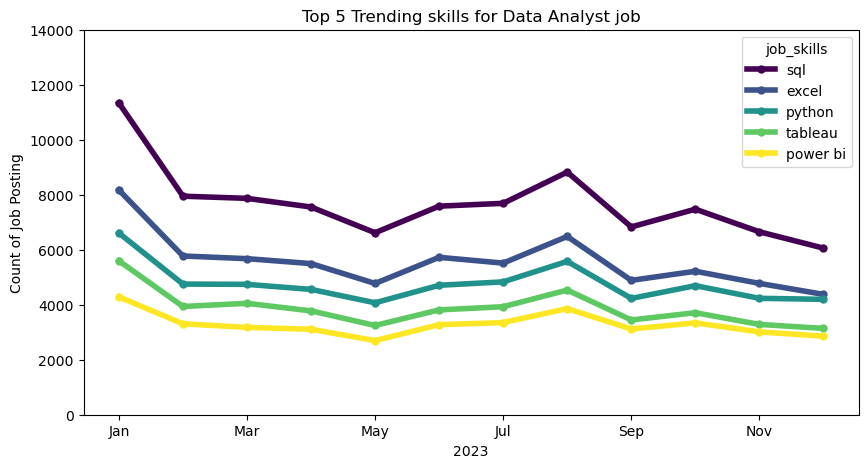

In [61]:
df_DA_pivot.iloc[:,:5].plot(
    kind='line',
    linewidth= 4,
    linestyle='-', # options ':','-','--','-.'
    colormap='viridis', # options 'viridis','plasma','magma','inferno', 'cividis' check the cheatsheet for more colors
    marker='o', # options 'o','x','+','*','s', ',' ,'.','1','2','3','4'...
    markersize =5,
    figsize=(10,5)
)

plt.title('Top 5 Trending skills for Data Analyst job')
plt.ylim(0, 14000)
plt.xlabel('2023')
plt.ylabel('Count of Job Posting')
plt.show()

# Advanced Customization for Scatter Plot

In [69]:
df_DA = df[df['job_title_short'] == 'Data Analyst']
df_DA_exploded = df_DA.explode('job_skills')
df_DA_scatter = df_DA_exploded.groupby('job_skills').agg(
    skill_count=('job_skills','count'),
    median_salary=('salary_year_avg','median')
)
count = 20
df_DA_scatter = df_DA_scatter.sort_values(by='skill_count', ascending=False).head(count)
df_DA_scatter

,skill_count,median_salary
job_skills,,
sql,92428,92500.000000
excel,66860,84479.000000
python,57190,98500.000000
tableau,46455,95000.000000
power bi,39380,90000.000000
r,29996,92527.500000
sas,27998,90000.000000
powerpoint,13822,85000.000000
word,13562,80000.000000


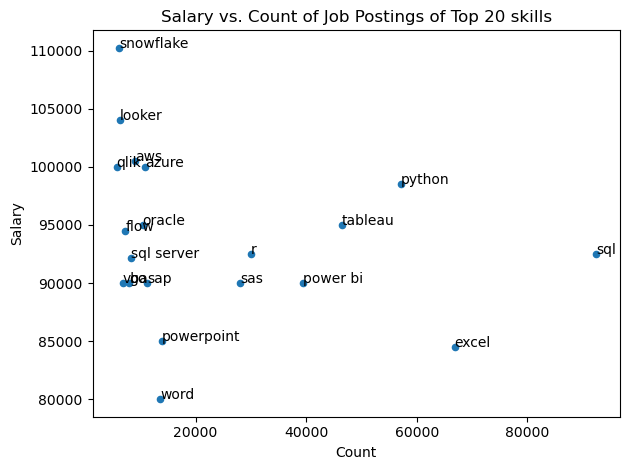

In [74]:
df_DA_scatter.plot(kind='scatter', x = 'skill_count', y='median_salary')

for i, txt in enumerate(df_DA_scatter.index):
    plt.text(df_DA_scatter['skill_count'].iloc[i], df_DA_scatter['median_salary'].iloc[i], txt)

plt.title(f'Salary vs. Count of Job Postings of Top {count} skills')
plt.ylabel('Salary')
plt.xlabel('Count')
plt.tight_layout()
plt.show()

In [71]:
list(enumerate(df_DA_scatter.index))

[(0, 'sql'),
 (1, 'excel'),
 (2, 'python'),
 (3, 'tableau'),
 (4, 'power bi'),
 (5, 'r'),
 (6, 'sas'),
 (7, 'powerpoint'),
 (8, 'word'),
 (9, 'sap'),
 (10, 'azure'),
 (11, 'oracle'),
 (12, 'aws'),
 (13, 'sql server'),
 (14, 'go'),
 (15, 'flow'),
 (16, 'vba'),
 (17, 'looker'),
 (18, 'snowflake'),
 (19, 'qlik')]

In [75]:
# it looks conjusted in order to make it more understandable and to adjust text we can use adjust_text
# for that first install adjust_text to your environment


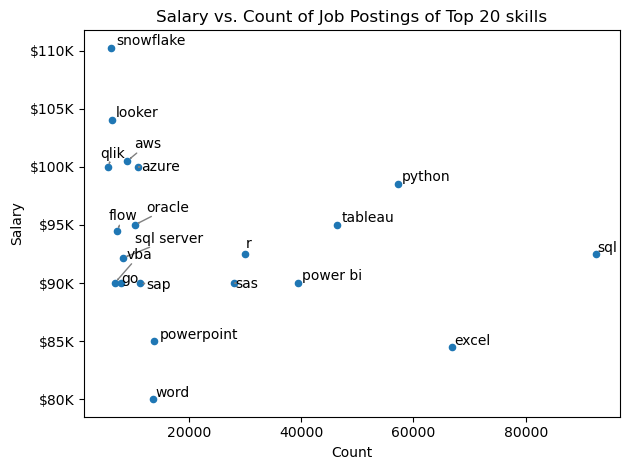

In [82]:
from adjustText import adjust_text
df_DA_scatter.plot(kind='scatter', x = 'skill_count', y='median_salary')

texts = []
for i, txt in enumerate(df_DA_scatter.index):
    texts.append(plt.text(df_DA_scatter['skill_count'].iloc[i], df_DA_scatter['median_salary'].iloc[i], txt))

adjust_text(texts, arrowprops=dict(arrowstyle="->" , color='gray', lw=1))

ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K'))

plt.title(f'Salary vs. Count of Job Postings of Top {count} skills')
plt.ylabel('Salary')
plt.xlabel('Count')
plt.tight_layout()
plt.show()